# 📊 Sectioned Summary Table Visualization

This notebook demonstrates how to use the `sectioned_summary_table_viz.py` tool. This visualization is designed to show a breakdown of multiple metrics across different categories (sections) for a specific group of players, using percentile ranks to compare them against the rest of the dataset.

## 📋 Step 1: Libraries and Path Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the src directory to the path so we can import the visualization module
sys.path.append(os.path.abspath('../../../src'))

from visualization.sectioned_summary_table_viz import ranking_plot

## 📥 Step 2: Load Data

We will load the AUS A-League physical aggregates for the 2024/2025 season.

In [3]:
data_path = '../../../data/aggregates/aus1league_physicalaggregates_20242025.csv'
df = pd.read_csv(data_path)

print(f"Loaded {len(df)} rows")
df.head()

Loaded 406 rows


,player_name,player_short_name,player_id,player_birthdate,team_name,team_id,competition_name,competition_id,season_name,season_id,...,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip
0,Adam Taggart,A. Taggart,211,1993-06-02,Perth Glory Football Club,871,AUS - A-League,61,2024/2025,95,...,48.46,3.00,297.83,27.21,42.38,2.67,38.25,6.96,1.92,0.08
1,Adama Traoré,A. Traoré,218,1990-02-03,Melbourne Victory Football Club,868,AUS - A-League,61,2024/2025,95,...,69.67,4.00,315.33,25.00,37.83,2.00,25.67,4.50,1.17,0.50
2,Dino Arslanagić,D. Arslanagić,2759,1993-04-24,Macarthur FC,1804,AUS - A-League,61,2024/2025,95,...,29.12,1.25,223.25,16.88,45.12,1.75,30.75,3.50,1.25,0.00
3,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,28.00,2.00,227.25,17.50,28.75,2.00,25.00,3.00,0.75,0.25
4,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,1.00,0.00,170.00,16.00,26.00,0.00,21.00,2.00,0.00,0.00


## 📂 Step 3: Normalization and Filtering

Matching the approach in the Z-score tutorial, we perform the following:
1. Filter for players with at least 5 matches.
2. Normalize cumulative metrics to **Per 90 (P90)** to allow fair comparison.

In [19]:
# Initial filtering
df_filtered = df[(df['count_match'] >= 5) & (df['minutes_full_all'] > 60)].copy()

# Normalize key metrics to P90
metrics_to_normalize = {
    'hi_count_full_all': 'hi_count_p90',
    'sprint_distance_full_all': 'sprint_distance_p90',
    'total_distance_full_all': 'total_dist_p90',
    'running_distance_full_all': 'running_dist_p90',
    'highaccel_count_full_all': 'highaccel_p90',
    'explacceltosprint_count_full_all': 'explacceltosprint_p90'
}

for raw_col, p90_col in metrics_to_normalize.items():
    df_filtered[p90_col] = (df_filtered[raw_col] / df_filtered['minutes_full_all']) * 90

print(f"Data filtered to {len(df_filtered)} records and normalized.")

Data filtered to 210 records and normalized.


## 📊 Step 4: Visualization Setup

We need to define:
1. **Questions**: A dictionary mapping section labels to lists of metrics.
2. **Highlight Group**: The list of players we want to display in the table.

In [24]:
# Sectioned metrics definition
questions = {
    'Intensity': ['hi_count_p90', 'sprint_distance_p90'],
    'Volume': ['total_dist_p90', 'total_metersperminute_full_tip','total_metersperminute_full_otip'],
    'Explosivity': ['highaccel_p90', 'explacceltosprint_p90']
}

# Metric labels for cleaner output
metric_labels = {
    'hi_count_p90': 'HI Count',
    'sprint_distance_p90': 'Sprint Distance',
    'total_dist_p90': 'Total Distance',
    'total_metersperminute_full_tip': 'Meters Per Minute TIP',
    'total_metersperminute_full_otip': 'Meters Per Minute OTIP',
    'highaccel_p90': 'High Accels',
    'explacceltosprint_p90': 'Explosive Accels'
}

# Select a group of players for comparison (e.g., players from Sydney FC)
highlight_players = df_filtered[df_filtered['team_name'] == 'Sydney Football Club']['player_name'].unique()[:6]


## 🎨 Step 5: Render the Sectioned Summary Table

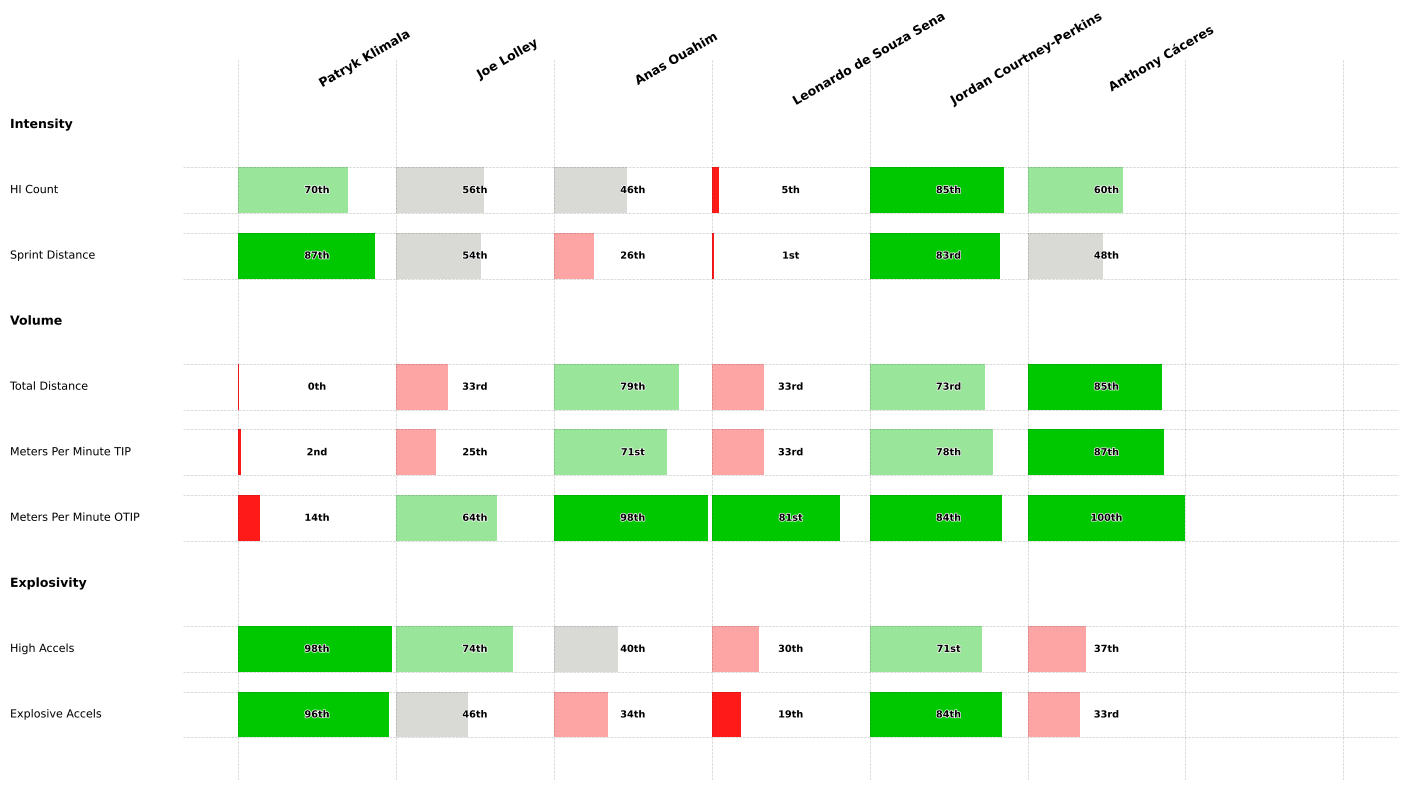

In [25]:
fig, ax = ranking_plot(
    df=df_filtered, 
    questions=questions, 
    highlight_group=highlight_players,
    metric_labels=metric_labels,
    figsize=(14, 8)
)

### Alternative Visualization: Bubble Mode
We can also use `user_circles=True` to render the ranks as expanding bubbles instead of bars.

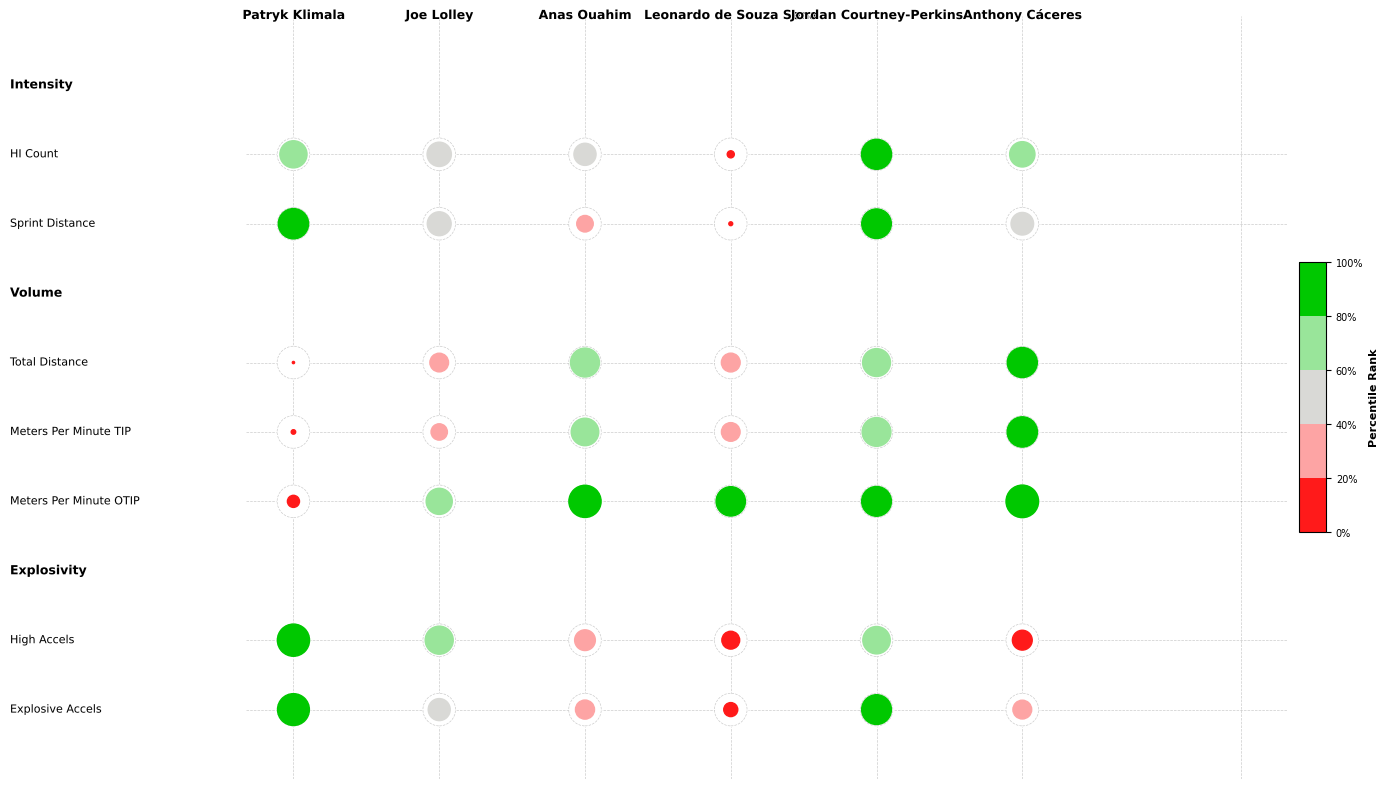

In [26]:
fig, ax = ranking_plot(
    df=df_filtered, 
    questions=questions, 
    highlight_group=highlight_players,
    metric_labels=metric_labels,
    user_circles=True,
    figsize=(14, 8)
)